In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data_set=load_dataset('lukebarousse/data_jobs')
df = data_set['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
import ast
def clean_list(x):
    if pd.notna(x):
        return ast.literal_eval(x)
df['job_skills']=df['job_skills'].apply(clean_list)
df_DA_VN=df[(df['job_title_short']=='Data Analyst') &  (df['job_country']=='Vietnam')].copy()


In [10]:
df_plot=df_DA_VN['job_location'].value_counts().head(10).to_frame()
df_plot

,count
job_location,
"Ho Chi Minh City, Vietnam",119
Vietnam,91
"Hanoi, Vietnam",39
"Hanoi, Hoàn Kiếm, Hanoi, Vietnam",31
Anywhere,19
"Da Nang, Hải Châu District, Da Nang, Vietnam",15
"Da Nang, Vietnam",3
"Binh Duong, Vietnam",3
"Tân Bình, Ho Chi Minh City, Vietnam",2


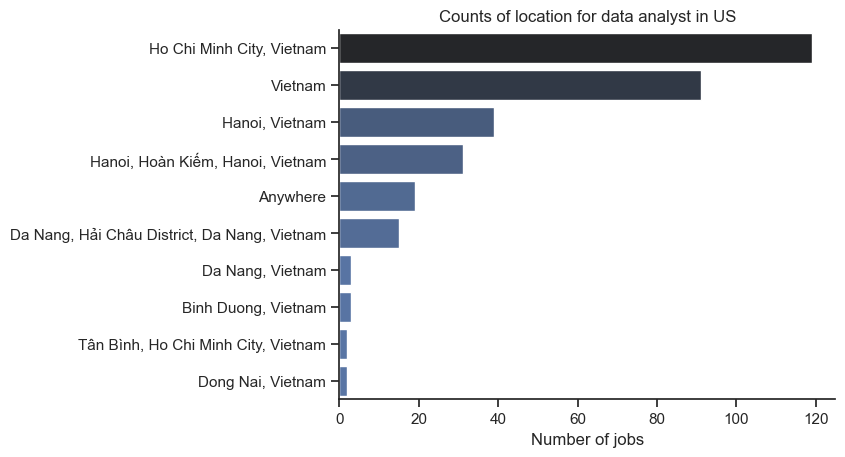

In [ ]:
sns.barplot(data=df_plot,x='count',y='job_location',hue='count',palette='dark:b_r')
sns.set_theme(style='ticks')
sns.despine()
plt.legend().remove()     
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.title("Counts of location for data analyst in VN")
plt.show()

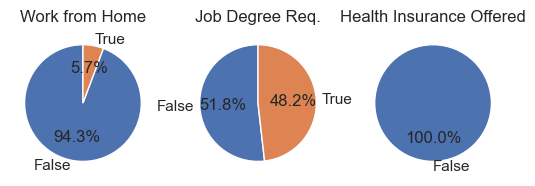

In [21]:
fig, ax = plt.subplots(1, 3)
#fig.set_size_inches(12,5)
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i,(column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_VN[column].value_counts(),labels=df_DA_VN[column].value_counts().index,autopct='%1.1f%%',startangle=90)
    ax[i].set_title(title)
plt.show()

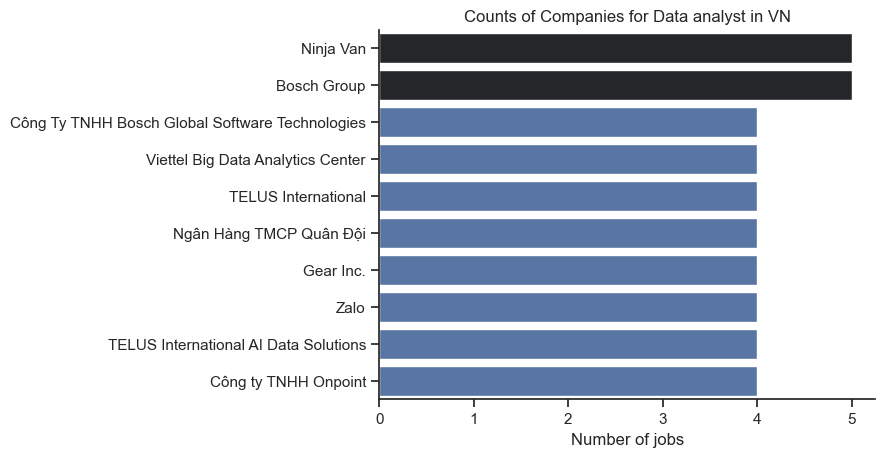

In [25]:
df_plot=df_DA_VN['company_name'].value_counts().head(10).to_frame()
sns.barplot(data=df_plot,x='count',y='company_name',hue='count',palette='dark:b_r')
sns.set_theme(style='ticks')
sns.despine()
plt.legend().remove()     
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.title("Counts of Companies for Data analyst in VN")
plt.show()